# Practical Application: Acoustic Noise Reduction in Motion-Compensated Diffusion

In advanced Diffusion MRI (like cardiac or liver diffusion), it is common to enforce **Motion-Compensated (M0, M1, M2 = 0)** gradient waveforms. However, forcing multi-moment nulling causes the gradient waveform to heavily oscillate. These fast oscillations frequently hit the **Mechanical Resonance Modes** of the scanner's gradient coil, creating extremely loud and sometimes unsafe acoustic vibrations.

In this notebook, we design a highly constrained **practical diffusion sequence** mimicking this scenario.
We will:
1. Generate a standardized motion-compensated waveform (the "Base Case") and observe the primary acoustic frequencies it excites.
2. Introduce the `Op_Acoustic` constraint to actively suppress specific "forbidden" scanner resonance bands that the base sequence inadvertently triggered.
3. Visually validate how the optimization negotiates between the hardware geometry, the zero-moments, and the B-value to completely squash the offending acoustic energy.

In [55]:
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import numpy as np
import gropt
from gropt.diff import *

In [56]:
[asc_file, extra] = gropt.readasc.readasc(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')
# print(asc_file)
forbidden_frequency = gropt.readasc.asc_to_acoustic_resonances(asc_file)
# print(forbidden_frequency)
[safe_params, safe_params_cardiac] = gropt.readasc.asc_to_safe(r'E:\MGH\Healthy_Grad\asc\CimaX.asc')
# print(safe_params)

In [57]:
dt = 100e-6
T_90 = 2.4e-3
T_180 = 5.3e-3
T_readout = 16e-3
b = 2000
TE = 70e-3

gmax = 0.2
smax = 200

# TE = diff_min_TE()

### 1. Motion Compensated Diffusion Baseline
Let's enforce a gradient with max limits, an exact target `B-value = 500 s/mm^2`, and strict zero-moment conditions representing typical Flow/Vibration compensation ($M_0 = M_1 = M_2 = 0$).

In [58]:
gparams_base = gropt.GroptParams()

# Realistic scan timing parameters (Increased TE to 90ms to allow physical convergence without M2)
gparams_base.diff_init(dt=dt, TE=TE, T_90=T_90, T_180=T_180, T_readout=T_readout)

# Strict hardware limits
gparams_base.add_gmax(gmax)           # 200 mT/m max gradient amplitude
gparams_base.add_smax(smax)           # 200 T/m/s max slew rate

# Multi-Moment nulling
gparams_base.add_moment(0, 0.0)      # M0 = 0 (Base position phase)
gparams_base.add_moment(1, 0.0)      # M1 = 0 (Velocity/Flow compensation)

# Add Total Variation (TV) specifically to create a smooth base curve, minimizing noise
gparams_base.add_TV(1e-3, 5)
gparams_base.add_TV2(1e1, 5)

gparams_base.add_SAFE(0.8, safe_params=safe_params)
gparams_base.add_SAFE(0.8, safe_params=safe_params_cardiac)

# Target B-Value (500 s/mm^2)
gparams_base.add_bvalue(b, 1)

gparams_base.print_op_details()

print("Solving Base Oscillating Sequence...")
start_t = timer()
solver = gropt.SolverGroptSDMM()
# solver = gropt.SolverOSQP()
result_base = solver.solve(gparams_base)
stop_t = timer()

out_base = result_base.X
print(f'Base Converged: {result_base.converged} | Solve time: {1000*(stop_t-start_t):.1f} ms')

Solving Base Oscillating Sequence...
Base Converged: True | Solve time: 634.5 ms


### 2. Targeting Scanner Resonance Overlaps
The oscillating gradients in the "Base Case" naturally end up dumping immense power spectral density into specific frequency bands. 
If a scanner's mechanical frame happens to have bending modes around **90 Hz** and **145 Hz**, this sequence will sound like a jackhammer.

We can deploy our new `Op_Acoustic` to define notch exclusion bands precisely where those scanner resonances lie, forcing the convex optimization to reroute the power to safer bands.

In [59]:
# The acoustic solver will use the exact same ac setup
gparams_ac = gropt.GroptParams()

# Realistic scan timing parameters (Increased TE to 90ms to allow physical convergence without M2)
gparams_ac.diff_init(dt=dt, TE=TE, T_90=T_90, T_180=T_180, T_readout=T_readout)

# Strict hardware limits
gparams_ac.add_gmax(gmax)           # 200 mT/m max gradient amplitude
gparams_ac.add_smax(smax)           # 100 T/m/s max slew rate

# Multi-Moment nulling
gparams_ac.add_moment(0, 0.0)      # M0 = 0 (ac position phase)
gparams_ac.add_moment(1, 0.0)      # M1 = 0 (Velocity/Flow compensation)

# Add Total Variation (TV) specifically to create a smooth ac curve, minimizing noise
gparams_ac.add_TV(1e-3, 5)
gparams_ac.add_TV2(1e1, 5)

gparams_ac.add_SAFE(0.8, safe_params=safe_params)
gparams_ac.add_SAFE(0.8, safe_params=safe_params_cardiac)

# Target B-Value (500 s/mm^2)
gparams_ac.add_bvalue(b, 1)

# Let's inspect the acline sequence and target the low frequency peak that naturally occurs!
forbidden_frequencies = [f['frequency'] for f in forbidden_frequency]
forbidden_bandwidths = [f['bandwidth'] for f in forbidden_frequency]
print("Forbidden Frequencies (Hz):", forbidden_frequencies)
print("Forbidden Bandwidths (Hz):", forbidden_bandwidths)

# Less strict acoustic notch allowing more physical gradient to formulate b-value
gparams_ac.add_acoustic(forbidden_frequencies, forbidden_bandwidths, weight_mod=0.8, bw_scale=0.6)

print("Solving Acoustic Notched Sequence...")
start_t = timer()
solver = gropt.SolverGroptSDMM()
# solver = gropt.SolverOSQP()
result_ac = solver.solve(gparams_ac)
stop_t = timer()

out_ac = result_ac.X
print(f'Acoustic Notched Converged: {result_ac.converged} | Solve time: {1000*(stop_t-start_t):.1f} ms')

Forbidden Frequencies (Hz): [576, 1113]
Forbidden Bandwidths (Hz): [100, 344]
Solving Acoustic Notched Sequence...
Acoustic Notched Converged: True | Solve time: 2280.8 ms


### 3. Visual Validation
Notice how in the Time Domain the solver has discovered a completely different, slightly wider "stretching" path that successfully yields `b=500` without tripping any `smax` or $M_n=0$ bounds. And in the Frequency Domain PSD, the offending spikes originally sitting at 90Hz and 145Hz have been successfully squeezed identically to $0.0$.

Max PNS 0.793
Max CS 0.799
Max PNS Acoustic Constrained 0.607
Max CS Acoustic Constrained 0.794
b-value Reference Gradient 2000.128
b-value Acoustic Constrained 2000.083


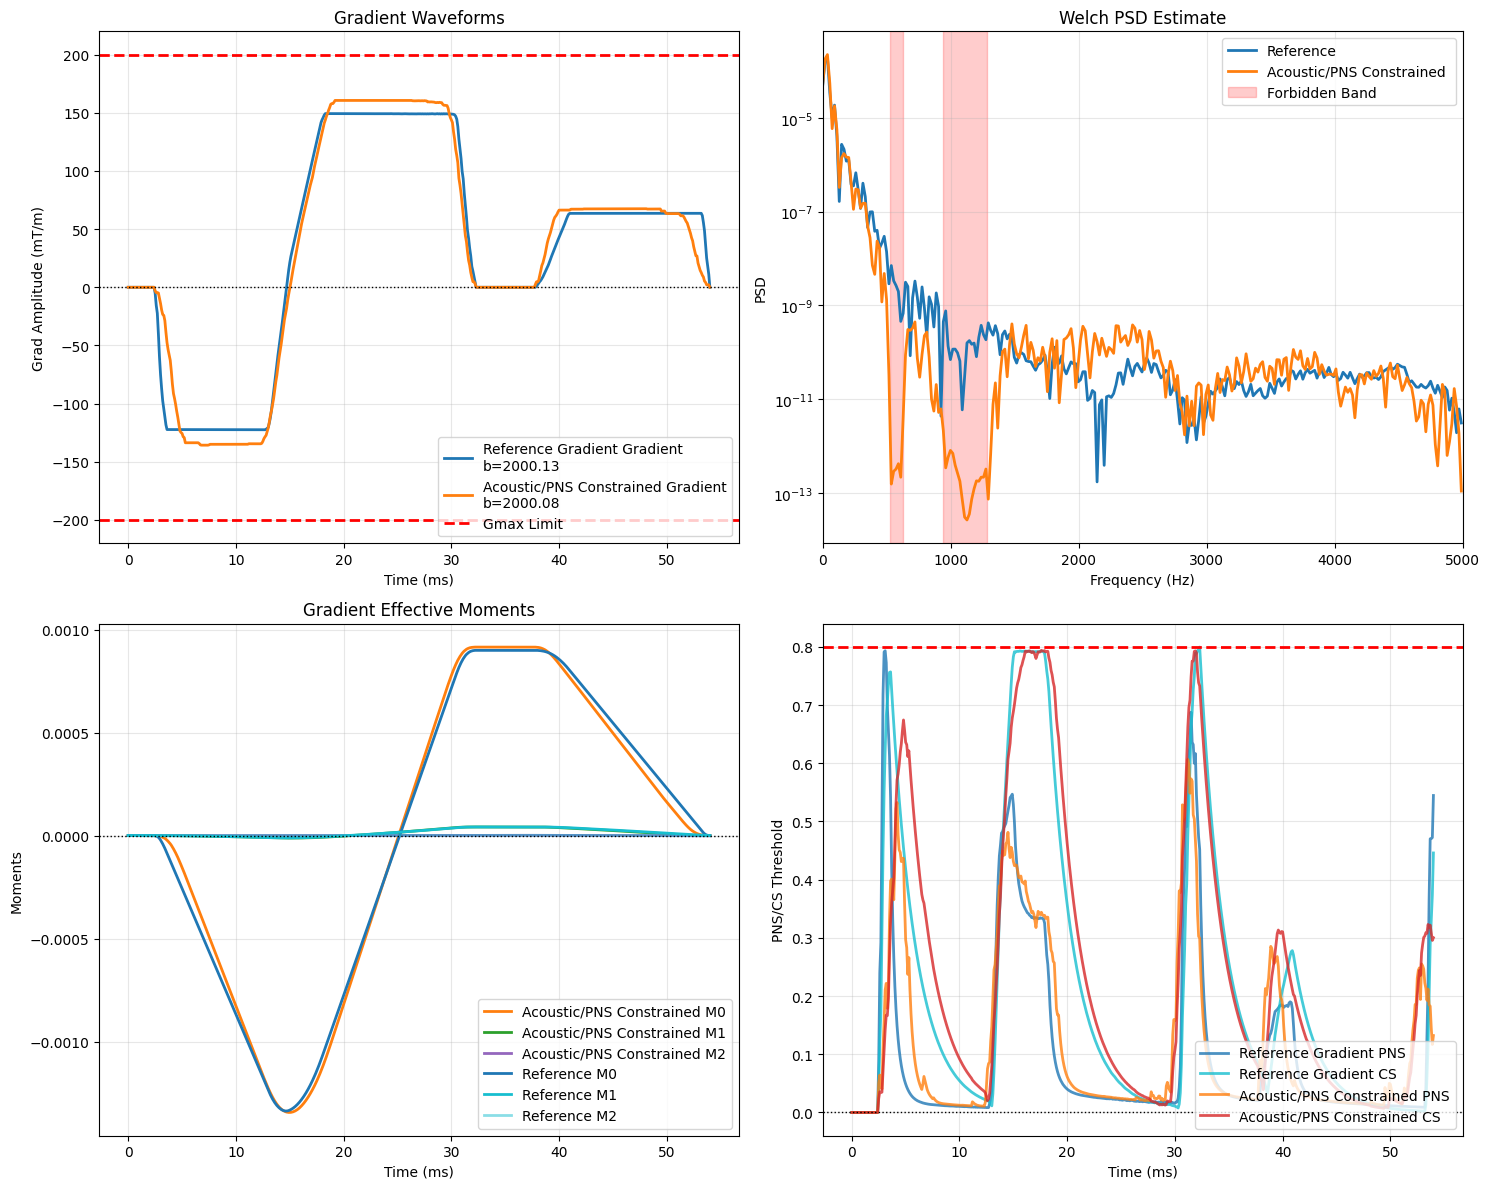

In [60]:
from scipy.signal import welch

# Welch PSD estimation
fs = 1.0 / gparams_base.dt
nperseg = min(2048, out_base.size)
noverlap = nperseg // 2

xf, psd_base = welch(out_base, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")
_, psd_ac = welch(out_ac, fs=fs, window="hann", nperseg=nperseg, noverlap=noverlap, scaling="density")

tt_ms = np.arange(out_base.size) * gparams_base.dt * 1e3

new_first_axis = 0
safe_base = gropt.gropt_wrapper.get_SAFE(out_base, gparams_base.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params)
safe_cardiac_base = gropt.gropt_wrapper.get_SAFE(out_base, gparams_base.dt, 
                                    new_first_axis=new_first_axis, 
                                    safe_params=safe_params_cardiac)
safe_ac = gropt.gropt_wrapper.get_SAFE(out_ac, gparams_base.dt,
                                    new_first_axis=new_first_axis,
                                    safe_params=safe_params)
safe_cardiac_ac = gropt.gropt_wrapper.get_SAFE(out_ac, gparams_base.dt,
                                    new_first_axis=new_first_axis,
                                    safe_params=safe_params_cardiac)
# Calculate b-value
bvalue_base = result_base.bvalue
bvalue_ac = result_ac.bvalue

# Build inversion vector representing the 180 pulse flip
# Center of 180 is typically at TE / 2 + T_90 / 2
t_s = tt_ms * 1e-3
t_180_center = (TE / 2) + (T_90 / 2)
inv_vec = np.ones_like(t_s)
inv_vec[t_s >= t_180_center] = -1

# Calculate moments using the *effective* gradient waveform
eff_out_base = out_base * inv_vec
eff_out_ac = out_ac * inv_vec

m0_base = np.cumsum(eff_out_base) * gparams_base.dt
m0_ac = np.cumsum(eff_out_ac) * gparams_ac.dt
m1_base = np.cumsum(eff_out_base * t_s) * gparams_base.dt
m1_ac = np.cumsum(eff_out_ac * t_s) * gparams_ac.dt
m2_base = np.cumsum(eff_out_base * t_s**2) * gparams_base.dt
m2_ac = np.cumsum(eff_out_ac * t_s**2) * gparams_ac.dt

print(f'Max PNS {np.max(safe_base):.3f}')
print(f'Max CS {np.max(safe_cardiac_base):.3f}')
print(f'Max PNS Acoustic Constrained {np.max(safe_ac):.3f}')
print(f'Max CS Acoustic Constrained {np.max(safe_cardiac_ac):.3f}')
print(f'b-value Reference Gradient {bvalue_base:.3f}')
print(f'b-value Acoustic Constrained {bvalue_ac:.3f}')

# Optional comparison plot
plt.figure(figsize=(15, 12))
plt.subplot(221)
plt.plot(tt_ms, out_base*1000, label="Reference Gradient Gradient\nb=" + f"{bvalue_base:.2f}", color="tab:blue", lw=2)
plt.plot(tt_ms, out_ac*1000, label="Acoustic/PNS Constrained Gradient\nb=" + f"{bvalue_ac:.2f}", color="tab:orange", lw=2)
plt.axhline(gmax*1000, color="red", linestyle="--", label="Gmax Limit", lw=2)
plt.axhline(-gmax*1000, color="red", linestyle="--", lw=2)
plt.axhline(0, c='k', linestyle=":", lw=1)
plt.xlabel("Time (ms)")
plt.ylabel("Grad Amplitude (mT/m)")
plt.title("Gradient Waveforms")
plt.grid(True, which="both", alpha=0.3)
plt.legend(loc='lower right')

plt.subplot(222)
plt.semilogy(xf, psd_base, label="Reference", color="tab:blue", lw=2)
plt.semilogy(xf, psd_ac, label="Acoustic/PNS Constrained ", color="tab:orange", lw=2)
for idx, (f, bw) in enumerate(zip(forbidden_frequencies, forbidden_bandwidths)):
    plt.axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red", label="Forbidden Band" if idx == 0 else None)
plt.xlim(0, 5000)
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD")
plt.title("Welch PSD Estimate")
plt.grid(True, which="both", alpha=0.3)
plt.legend()

plt.subplot(223)
# plt.plot(tt_ms[:-1], np.diff(out_base)/gparams_base.dt, label="Reference Gradient Gradient Slew Rate", color="tab:blue", lw=2)
# plt.plot(tt_ms[:-1], np.diff(out_ac)/gparams_base.dt, label="Acoustic/PNS Constrained Gradient Slew Rate", color="tab:orange", lw=2)
# plt.axhline(smax, color="red", linestyle="--", label="Smax Limit", lw=2)
# plt.axhline(-smax, color="red", linestyle="--", lw=2)
plt.plot(tt_ms, m0_ac, label="Acoustic/PNS Constrained M0", color="tab:orange", lw=2)
plt.plot(tt_ms, m1_ac, label="Acoustic/PNS Constrained M1", color="tab:green", lw=2)
plt.plot(tt_ms, m2_ac, label="Acoustic/PNS Constrained M2", color="tab:purple", lw=2)

plt.plot(tt_ms, m0_base, label="Reference M0", color="tab:blue", lw=2)
plt.plot(tt_ms, m1_base, label="Reference M1", color="tab:cyan", lw=2)
plt.plot(tt_ms, m2_base, label="Reference M2", color="tab:cyan", lw=2, alpha=0.5)
plt.legend(loc='lower right')

plt.axhline(0, c='k', linestyle=":", lw=1)
plt.xlabel("Time (ms)")
plt.ylabel("Moments")
plt.title("Gradient Effective Moments")
plt.grid(True, which="both", alpha=0.3)
plt.subplot(224)
plt.plot(tt_ms, safe_base, label="Reference Gradient PNS", color="tab:blue", lw=2, alpha=0.8)
plt.plot(tt_ms, safe_cardiac_base, label="Reference Gradient CS", color="tab:cyan", lw=2, alpha=0.8)
plt.plot(tt_ms, safe_ac, label="Acoustic/PNS Constrained PNS", color="tab:orange", lw=2, alpha=0.8)
plt.plot(tt_ms, safe_cardiac_ac, label="Acoustic/PNS Constrained CS", color="tab:red", lw=2, alpha=0.8)
plt.legend(loc='lower right')

plt.axhline(0.8, color="red", linestyle="--", label="SAFE Limit", lw=2)
plt.axhline(0, c='k', linestyle=":", lw=1)
plt.xlabel("Time (ms)")
plt.ylabel("PNS/CS Threshold")
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

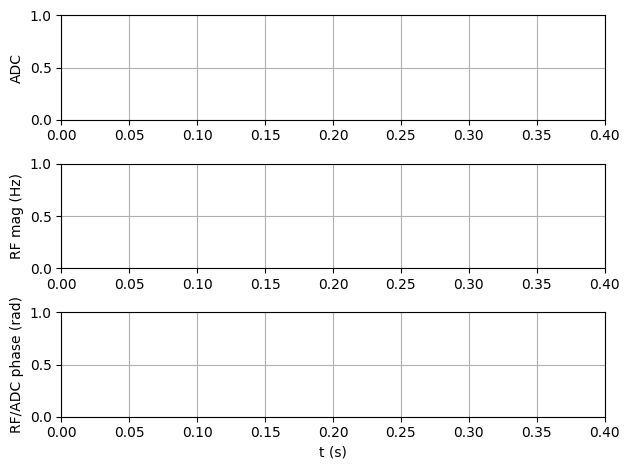

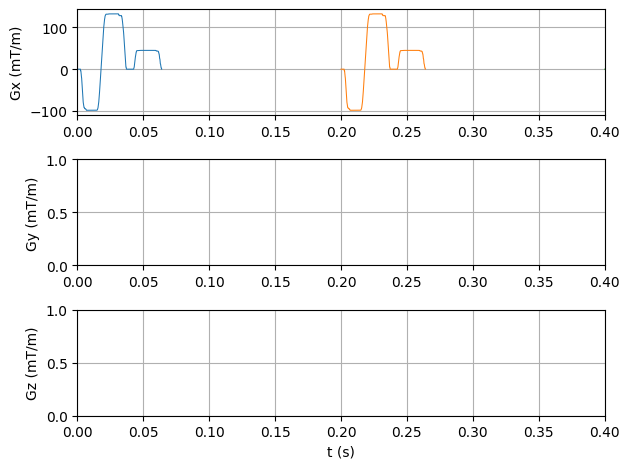

In [31]:
import pypulseq as pp

sys = pp.Opts(
    max_grad=200,
    grad_unit='mT/m',
    max_slew=220,  # T/m/s
    slew_unit='T/m/s',
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=20e-6
)

trigger = pp.make_digital_output_pulse(channel='ext1', delay=0, duration=20e-6)

grad_ac = pp.make_extended_trapezoid(channel='x', system=sys, amplitudes=out_ac*sys.gamma, times=np.arange(out_ac.size)*gparams_ac.dt)
grad_base = pp.make_extended_trapezoid(channel='x', system=sys, amplitudes=out_base*sys.gamma, times=np.arange(out_base.size)*gparams_base.dt)

TR = 200e-3
num_rep = 20

channel_list = ['x', 'y', 'z']
seq = pp.Sequence(sys)
for ch in channel_list:
    for _ in range(num_rep):
        grad_ac.channel = ch
        seq.add_block(trigger, grad_ac, pp.make_delay(TR))
    for _ in range(num_rep):
        grad_base.channel = ch
        seq.add_block(trigger, grad_base, pp.make_delay(TR))
seq.check_timing()
seq.plot(time_range=(0, 2*TR), grad_disp='mT/m')

In [52]:
version = '0.0.5'
seq.write('seq/acoustic_validation_seq_'+version+'.seq')

'b4d65167e1968c5c1d0ddae5f0803a03'

### 4. Minimizing Echo Time using `diff_min_TE` (Bisection Search)

We can utilize the `diff_min_TE` bisection tool loaded from `gropt.diff` to numerically pinpoint the absolute minimum Echo Time (TE) physically capable of containing our B-value target (`1000 s/mm^2`), our M0=M1=0 flow-compensation limits, and our Acoustic Resonance Notches all together.

*Note: The tool internally utilizes the robust OSQP solver. It brackets a physical minimum TE bound based on the RF envelopes, then iteratively tightens TE until the gradient waveform can no longer physically accommodate the target B-value (returns an infeasible domain).*

In [53]:
from gropt.diff import diff_min_TE
import gropt.diff as diff
import importlib
importlib.reload(diff)

# Package all of our hardware, acoustic, and moment constraint parameters into the search dict
search_params = {
    'bvalue': b,                 # Target 1000 s/mm²
    'dt': dt,                    # 100 µs res
    'T_90': T_90,                # 2.4 ms
    'T_180': T_180,              # 5.3 ms
    'T_readout': T_readout,      # 16 ms
    'gmax': gmax,                # 200 mT/m
    'smax': smax,                # 200 T/m/s
    'MMT': 1,                    # M0 = M1 = 0
    'pns_lim': 0.8,
    'pns_params': safe_params,
    'cns_lim': 0.8,
    'cns_params': safe_params_cardiac,
    'tv_lam': 1e-3,              # Smooth L1 Total Variation penalty
    'tv2_lam': 5e0,             # Penalize max slew rate jerk/noise
    # 'acoustic': {                # The active forbidden acoustic notches
    #     'freqs': forbidden_frequencies,
    #     'bws': forbidden_bandwidths
    # }
}

# Launch the bisection search using SDMM
print("Launching Bisection Search for Minimum Echo Time ...")
best_TE, result_min = diff.diff_min_TE(search_params, target_bval=b)

if best_TE:
    print(f"\n=> SUCCESS: Absolute Minimum Physical TE: {best_TE * 1000.0:.2f} ms")
    print(f"=> Achieved B-Value: {result_min.bvalue:.2f} s/mm²")
    
    # Store standard outputs for the plotting cell
    out_min = result_min.X
else:
    print("=> FAILED: Space is infeasible. Cannot fit sequence.")

Launching Bisection Search for Minimum Echo Time ...
Searching TE: 86.30 69.45 77.88 73.66 75.77 76.82 76.30 76.03 75.90 75.83 Done!
Refining at Best TE: 75.83 ms with exact target B-value...

=> SUCCESS: Absolute Minimum Physical TE: 75.83 ms
=> Achieved B-Value: 1999.01 s/mm²


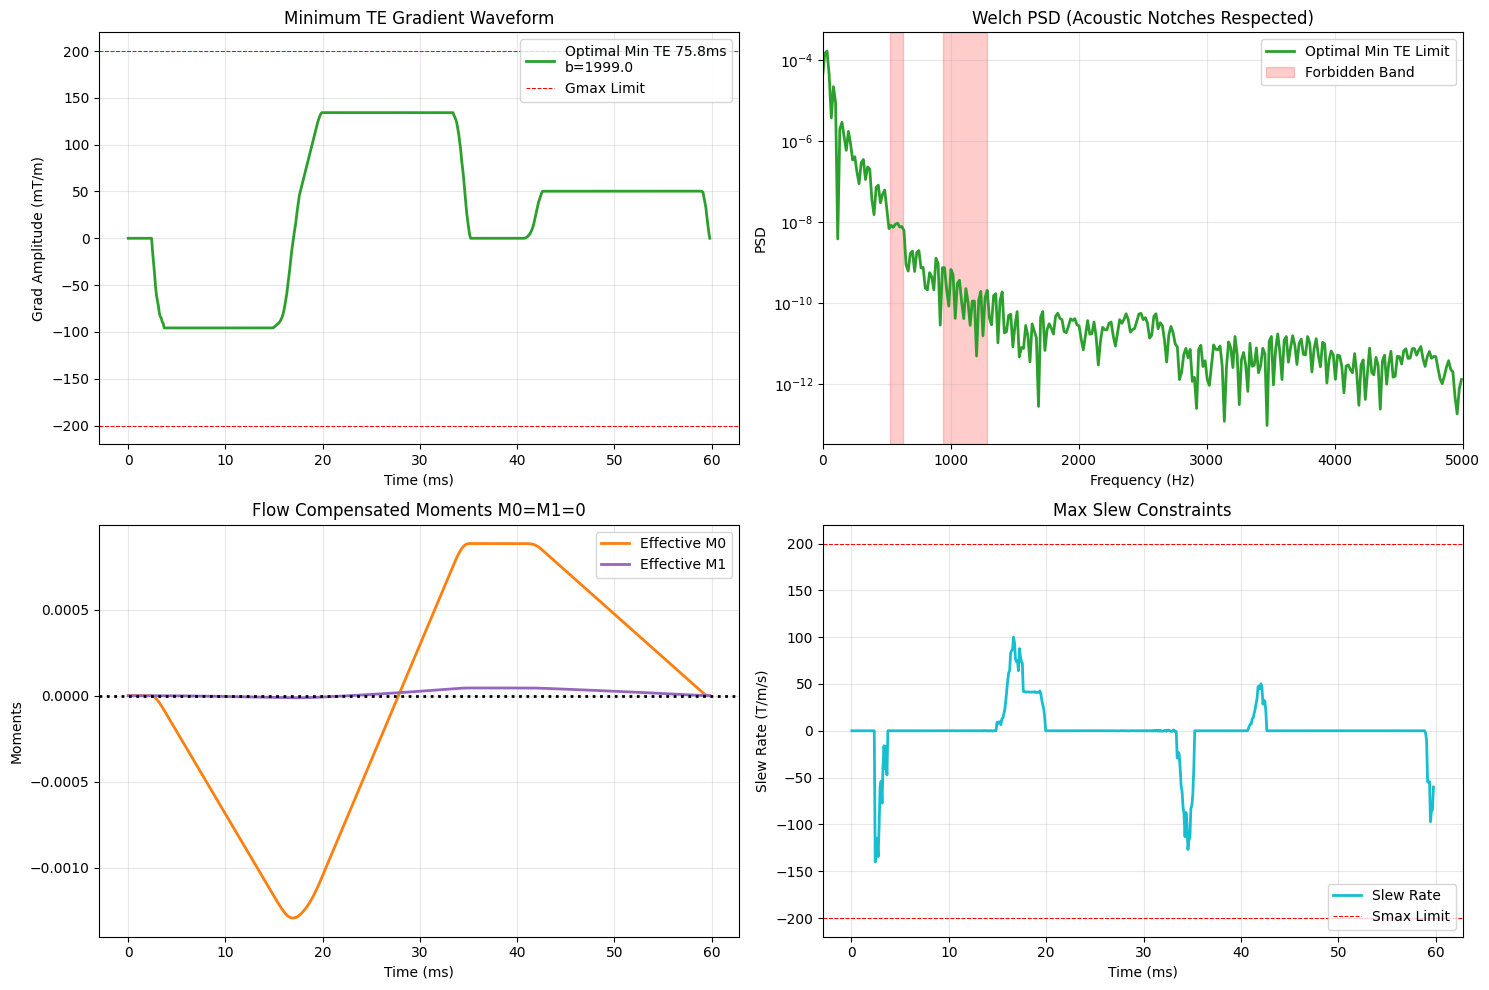

In [54]:
if best_TE:
    out_min = result_min.X
    tt_min_ms = np.arange(out_min.size) * dt * 1e3
    bvalue_min = result_min.bvalue
    
    # Calculate Moments
    t_s = tt_min_ms * 1e-3
    t_180_center = (best_TE / 2) + (T_90 / 2)
    inv_vec = np.ones_like(t_s)
    inv_vec[t_s >= t_180_center] = -1
    eff_out_min = out_min * inv_vec
    
    m0_min = np.cumsum(eff_out_min) * dt
    m1_min = np.cumsum(eff_out_min * t_s) * dt
    
    # Calculate PSD
    fs = 1.0 / dt
    nperseg_min = min(2048, out_min.size)
    noverlap_min = nperseg_min // 2
    xf_min, psd_min = welch(out_min, fs=fs, window="hann", nperseg=nperseg_min, noverlap=noverlap_min, scaling="density")

    # Hardware Limits lines
    plt.figure(figsize=(15, 10))
    ax1 = plt.subplot(221)
    ax1.plot(tt_min_ms, out_min * 1000, color='tab:green', lw=2, label=f"Optimal Min TE {best_TE*1000:.1f}ms\nb={bvalue_min:.1f}")
    ax1.axhline(gmax*1000, color="red", linestyle="--", label="Gmax Limit")
    ax1.axhline(-gmax*1000, color="red", linestyle="--")
    ax1.set_xlabel("Time (ms)")
    ax1.set_ylabel("Grad Amplitude (mT/m)")
    ax1.set_title("Minimum TE Gradient Waveform")
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    ax2 = plt.subplot(222)
    ax2.semilogy(xf_min, psd_min, color='tab:green', lw=2, label="Optimal Min TE Limit")
    for idx, (f, bw) in enumerate(zip(forbidden_frequencies, forbidden_bandwidths)):
        ax2.axvspan(f - bw / 2, f + bw / 2, alpha=0.2, color="red", label="Forbidden Band" if idx == 0 else None)
    ax2.set_xlim(0, 5000)
    # ax2.set_ylim(1e-12, 1e-2)
    ax2.set_xlabel("Frequency (Hz)")
    ax2.set_ylabel("PSD")
    ax2.set_title("Welch PSD (Acoustic Notches Respected)")
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    ax3 = plt.subplot(223)
    ax3.plot(tt_min_ms, m0_min, color='tab:orange', lw=2, label="Effective M0")
    ax3.plot(tt_min_ms, m1_min, color='tab:purple', lw=2, label="Effective M1")
    ax3.axhline(0, color='k', linestyle=':', lw=2)
    ax3.set_xlabel("Time (ms)")
    ax3.set_ylabel("Moments")
    ax3.set_title("Flow Compensated Moments M0=M1=0")
    ax3.grid(True, alpha=0.3)
    ax3.legend()

    ax4 = plt.subplot(224)
    # Check max slew rate
    slew_rate = np.diff(out_min) / dt
    tt_slew = tt_min_ms[:-1] + (dt * 1e3)/2
    ax4.plot(tt_slew, slew_rate, color='tab:cyan', lw=2, label="Slew Rate")
    ax4.axhline(smax, color="red", linestyle="--", label="Smax Limit")
    ax4.axhline(-smax, color="red", linestyle="--")
    ax4.set_xlabel("Time (ms)")
    ax4.set_ylabel("Slew Rate (T/m/s)")
    ax4.set_title("Max Slew Constraints")
    ax4.grid(True, alpha=0.3)
    ax4.legend(loc='lower right')
    
    plt.tight_layout()
    plt.show()